# Homework 3 Solution

In [1]:
import os

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("dark_background")
sns.set_palette("husl")
plt.rcParams.update(
    {
        "figure.facecolor": "#111111",
        "axes.facecolor": "#111111",
        "axes.edgecolor": "#aaaaaa",
        "text.color": "#ffffff",
        "xtick.color": "#aaaaaa",
        "ytick.color": "#aaaaaa",
    }
)

os.makedirs("./figures", exist_ok=True)

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf

## Problem 1

In [3]:
def gen_p1_data():
    mean = [0, 0]
    cov = [[1, 0.99999], [0.99999, 1]]
    x1, x2 = np.random.multivariate_normal(mean, cov, 100).T
    epsilon = np.random.normal(0, 1, 100)

    y = 1 + x1 + x2 + epsilon
    X = pd.DataFrame({"X1": x1, "X2": x2})
    return y, X

### 1.1

In [4]:
np.random.seed(1)
y_seed1, X_seed1 = gen_p1_data()
model = sm.OLS(y_seed1, sm.add_constant(X_seed1)).fit()
print(model.summary().as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &        y         & \textbf{  R-squared:         } &     0.733   \\
\textbf{Model:}            &       OLS        & \textbf{  Adj. R-squared:    } &     0.727   \\
\textbf{Method:}           &  Least Squares   & \textbf{  F-statistic:       } &     133.0   \\
\textbf{Date:}             & Sat, 19 Sep 2026 & \textbf{  Prob (F-statistic):} &  1.60e-28   \\
\textbf{Time:}             &     08:46:54     & \textbf{  Log-Likelihood:    } &   -141.69   \\
\textbf{No. Observations:} &         100      & \textbf{  AIC:               } &     289.4   \\
\textbf{Df Residuals:}     &          97      & \textbf{  BIC:               } &     297.2   \\
\textbf{Df Model:}         &           2      & \textbf{                     } &             \\
\textbf{Covariance Type:}  &    nonrobust     & \textbf{                     } &             \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
               & \textbf{coef} & \textb

### 1.2

In [5]:
np.random.seed(42)
y, X = gen_p1_data()
model2 = sm.OLS(y, sm.add_constant(X)).fit()
print(model2.summary().as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &        y         & \textbf{  R-squared:         } &     0.686   \\
\textbf{Model:}            &       OLS        & \textbf{  Adj. R-squared:    } &     0.679   \\
\textbf{Method:}           &  Least Squares   & \textbf{  F-statistic:       } &     105.9   \\
\textbf{Date:}             & Sat, 19 Sep 2026 & \textbf{  Prob (F-statistic):} &  4.13e-25   \\
\textbf{Time:}             &     08:46:54     & \textbf{  Log-Likelihood:    } &   -147.11   \\
\textbf{No. Observations:} &         100      & \textbf{  AIC:               } &     300.2   \\
\textbf{Df Residuals:}     &          97      & \textbf{  BIC:               } &     308.0   \\
\textbf{Df Model:}         &           2      & \textbf{                     } &             \\
\textbf{Covariance Type:}  &    nonrobust     & \textbf{                     } &             \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
               & \textbf{coef} & \textb

### 1.3 (Variance via Simulation)

beta1    22.449632
beta2    22.449454
dtype: float64


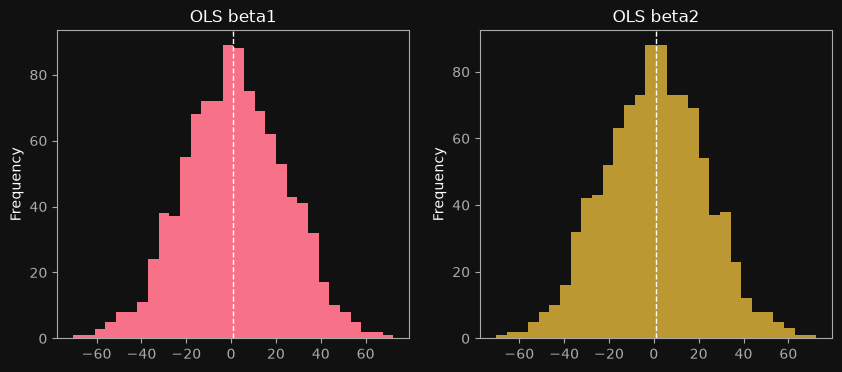

In [6]:
np.random.seed(0)
beta_ols = {"beta1": [], "beta2": []}
for _ in range(1000):
    y, X = gen_p1_data()
    m = sm.OLS(y, sm.add_constant(X)).fit()
    beta_ols["beta1"].append(m.params["X1"])
    beta_ols["beta2"].append(m.params["X2"])
beta_ols = pd.DataFrame(beta_ols)

ax = beta_ols.plot.hist(bins=30, subplots=True, layout=(1, 2), figsize=(10, 4), legend=False)
for a, col in zip(ax[0], beta_ols.columns):
    a.axvline(1, color="white", ls="--", lw=1)
    a.set_title(f"OLS {col}")
ax[0, 0].figure.savefig(
    "./figures/problem1_simulation_histograms.png", dpi=300, bbox_inches="tight"
)
print(beta_ols.std())

### 1.3 (Ridge to the Rescue)

Fit on the seed-1 dataset from 1.1, so the ridge coefficients are directly comparable
to the OLS coefficients reported there.

In [7]:
betas = []
for alpha in [0.01, 0.1, 1]:
    m = sm.OLS(y_seed1, sm.add_constant(X_seed1)).fit_regularized(L1_wt=0, alpha=alpha)
    betas.append(m.params)
betas = pd.DataFrame(betas, index=[0.01, 0.1, 1], columns=["const", "X1", "X2"])
betas.index.name = "alpha"
print(betas.to_latex(float_format="{:0.4f}".format))

\begin{tabular}{lrrr}
\toprule
 & const & X1 & X2 \\
alpha &  &  &  \\
\midrule
0.010000 & 0.9784 & 0.9720 & 0.9324 \\
0.100000 & 0.8713 & 0.8883 & 0.8850 \\
1.000000 & 0.3997 & 0.5358 & 0.5358 \\
\bottomrule
\end{tabular}



### 1.4 (Ridge Simulation)

Same seed as the OLS simulation above, so the two run on identical datasets.

\begin{tabular}{lrr}
\toprule
 & OLS & Ridge \\
\midrule
beta1 & 22.4496 & 0.0563 \\
beta2 & 22.4495 & 0.0562 \\
\bottomrule
\end{tabular}



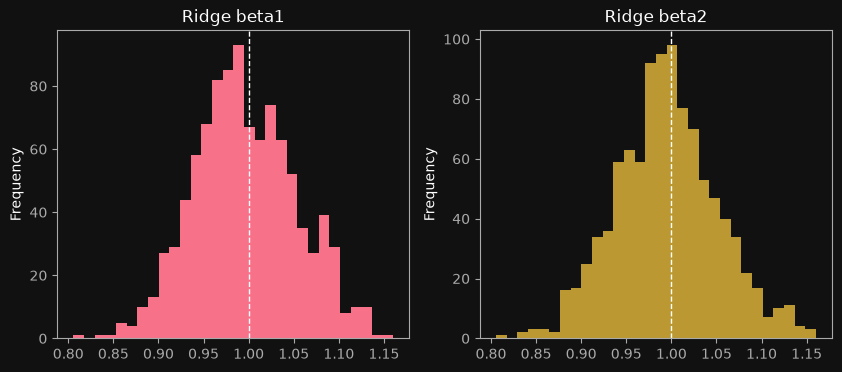

In [8]:
np.random.seed(0)
beta_ridge = {"beta1": [], "beta2": []}
for _ in range(1000):
    y, X = gen_p1_data()
    m = sm.OLS(y, sm.add_constant(X)).fit_regularized(L1_wt=0, alpha=0.01)
    beta_ridge["beta1"].append(m.params[1])
    beta_ridge["beta2"].append(m.params[2])
beta_ridge = pd.DataFrame(beta_ridge)

ax = beta_ridge.plot.hist(bins=30, subplots=True, layout=(1, 2), figsize=(10, 4), legend=False)
for a, col in zip(ax[0], beta_ridge.columns):
    a.axvline(1, color="white", ls="--", lw=1)
    a.set_title(f"Ridge {col}")
ax[0, 0].figure.savefig("./figures/problem1_ridge_histograms.png", dpi=300, bbox_inches="tight")

print(
    pd.DataFrame({"OLS": beta_ols.std(), "Ridge": beta_ridge.std()}).to_latex(
        float_format="{:0.4f}".format
    )
)

## Problem 2

In [9]:
np.random.seed(42)

n_samples = 100
n_features = 50

X = np.random.normal(0, 1, (n_samples, n_features))
true_beta = np.zeros(n_features)
true_beta[:3] = [5, -2, 3]

y = np.dot(X, true_beta) + np.random.normal(0, 1, n_samples)

### 2.1

In [10]:
model = sm.OLS(y, sm.add_constant(X)).fit()
noise = slice(4, None)  # const, X1, X2, X3, then the 47 noise features
print(f"noise coefficients exactly zero: {(model.params[noise] == 0).sum()} of 47")
print(f"largest noise coefficient in absolute value: {np.abs(model.params[noise]).max():.4f}")
print(f"noise coefficients with p < 0.05: {(model.pvalues[noise] < 0.05).sum()}")

noise coefficients exactly zero: 0 of 47
largest noise coefficient in absolute value: 0.4715
noise coefficients with p < 0.05: 4


### 2.2

In [11]:
for alpha in [0.1, 1, 100]:
    m = sm.OLS(y, sm.add_constant(X)).fit_regularized(L1_wt=1, alpha=alpha)
    nonzero = np.flatnonzero(m.params[1:] != 0)
    kept = [f"X{i + 1}" for i in nonzero]
    print(f"alpha={alpha}: {50 - len(kept)} of 50 exactly zero, kept {kept}")

alpha=0.1: 30 of 50 exactly zero, kept ['X1', 'X2', 'X3', 'X11', 'X14', 'X15', 'X16', 'X21', 'X24', 'X25', 'X26', 'X27', 'X31', 'X33', 'X34', 'X41', 'X42', 'X46', 'X49', 'X50']
alpha=1: 47 of 50 exactly zero, kept ['X1', 'X2', 'X3']
alpha=100: 50 of 50 exactly zero, kept []


In [12]:
m = sm.OLS(y, sm.add_constant(X)).fit_regularized(L1_wt=1, alpha=1)
print(pd.Series(m.params[1:4], index=["X1", "X2", "X3"]))

X1    3.778343
X2   -0.940298
X3    2.039199
dtype: float64


### 2.3

\begin{tabular}{lrrr}
\toprule
 & X1 & X2 & X3 \\
alpha &  &  &  \\
\midrule
0.001000 & 4.9344 & -1.9543 & 3.0572 \\
0.010000 & 4.9204 & -1.9444 & 3.0375 \\
0.100000 & 4.8256 & -1.8210 & 2.9424 \\
0.500000 & 4.3733 & -1.4323 & 2.5543 \\
1.000000 & 3.7783 & -0.9403 & 2.0392 \\
5.000000 & 0.0000 & 0.0000 & 0.0000 \\
10.000000 & 0.0000 & 0.0000 & 0.0000 \\
100.000000 & 0.0000 & 0.0000 & 0.0000 \\
1000.000000 & 0.0000 & 0.0000 & 0.0000 \\
\bottomrule
\end{tabular}



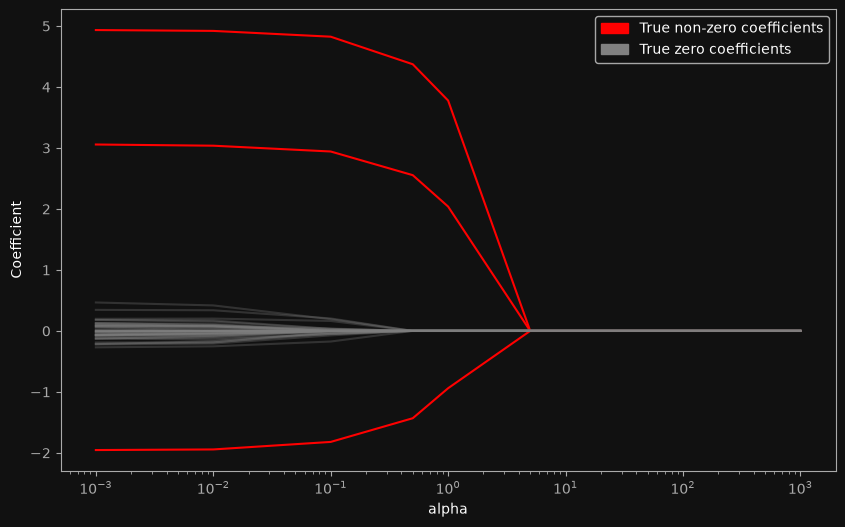

In [13]:
alphas = [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 100, 1000]
coeffs = pd.DataFrame(
    [sm.OLS(y, sm.add_constant(X)).fit_regularized(L1_wt=1, alpha=a).params for a in alphas],
    index=alphas,
    columns=["const"] + [f"X{i}" for i in range(1, n_features + 1)],
)
coeffs.index.name = "alpha"

ax = coeffs.plot(logx=True, figsize=(10, 6), legend=False)
for i in range(coeffs.shape[1]):
    if 1 <= i <= 3:
        ax.lines[i].set_color("red")
    else:
        ax.lines[i].set_color("grey")
        ax.lines[i].set_alpha(0.3)
ax.set_xlabel("alpha")
ax.set_ylabel("Coefficient")
ax.legend(
    handles=[
        mpatches.Patch(color="red", label="True non-zero coefficients"),
        mpatches.Patch(color="grey", label="True zero coefficients"),
    ]
)
ax.figure.savefig("./figures/problem2_lasso_path.png", dpi=300, bbox_inches="tight")

print(coeffs[["X1", "X2", "X3"]].to_latex(float_format="{:0.4f}".format))

## Problem 3

In [14]:
np.random.seed(100)
n = 1000

indicator = np.zeros(n)
for i in range(0, n, 200):
    indicator[i : i + 100] = 1

epsilon = np.zeros(n)
sigma2 = np.zeros(n)
epsilon[0] = np.random.normal(0, 1)

for t in range(1, n):
    sigma2[t] = 1 + 0.5 * (epsilon[t - 1] ** 2) + 10 * indicator[t]
    epsilon[t] = np.random.normal(0, np.sqrt(sigma2[t]))

y = np.zeros(n)
phi = 0.5
for t in range(1, n):
    y[t] = phi * y[t - 1] + epsilon[t]

### 3.1

In [15]:
ar1 = AutoReg(y, lags=1).fit()
print(ar1.summary().as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:} &             y             & \textbf{  No. Observations:  } &            1000            \\
\textbf{Model:}         &         AutoReg(1)        & \textbf{  Log Likelihood     } &         -2671.819          \\
\textbf{Method:}        &      Conditional MLE      & \textbf{  S.D. of innovations} &           3.510            \\
\textbf{Date:}          &      Sat, 19 Sep 2026     & \textbf{  AIC                } &          5349.639          \\
\textbf{Time:}          &          08:46:56         & \textbf{  BIC                } &          5364.359          \\
\textbf{Sample:}        &             1             & \textbf{  HQIC               } &          5355.234          \\
\textbf{}               &            1000           & \textbf{                     } &                            \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
               & \textbf{coef} & \textbf{std err} & \textbf{z} & \textbf{P$> |$z$|$}

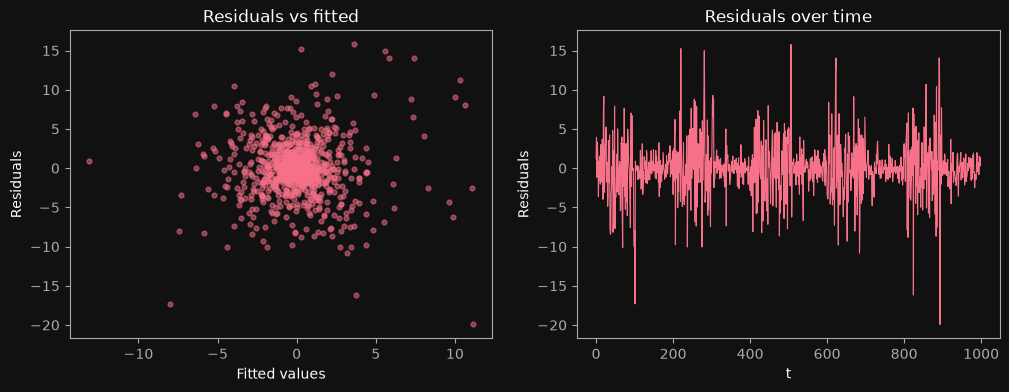

In [16]:
resid = ar1.resid
fitted = ar1.fittedvalues

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(fitted, resid, alpha=0.5, s=12)
ax[0].set_xlabel("Fitted values")
ax[0].set_ylabel("Residuals")
ax[0].set_title("Residuals vs fitted")
ax[1].plot(resid, lw=0.8)
ax[1].set_xlabel("t")
ax[1].set_ylabel("Residuals")
ax[1].set_title("Residuals over time")
fig.savefig("./figures/problem3_ar1_residuals.png", dpi=300, bbox_inches="tight")

### 3.2

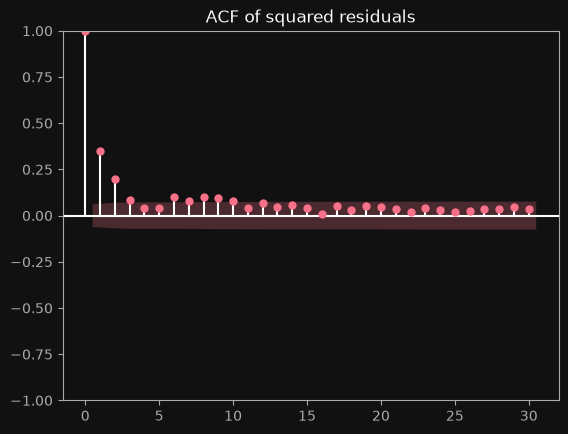

In [17]:
fig = plot_acf(resid**2, title="ACF of squared residuals")
fig.savefig("./figures/problem3_acf_squared_residuals.png", dpi=300, bbox_inches="tight")

### 3.3

In [18]:
resid2 = resid**2
var_data = pd.DataFrame(
    {"resid2": resid2[1:], "resid2_lag1": resid2[:-1], "indicator": indicator[2:]}
)

model_var = sm.OLS(
    var_data["resid2"], sm.add_constant(var_data[["resid2_lag1", "indicator"]])
).fit()
print(model_var.summary().as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &      resid2      & \textbf{  R-squared:         } &     0.155   \\
\textbf{Model:}            &       OLS        & \textbf{  Adj. R-squared:    } &     0.154   \\
\textbf{Method:}           &  Least Squares   & \textbf{  F-statistic:       } &     91.52   \\
\textbf{Date:}             & Sat, 19 Sep 2026 & \textbf{  Prob (F-statistic):} &  3.29e-37   \\
\textbf{Time:}             &     08:46:57     & \textbf{  Log-Likelihood:    } &   -4718.3   \\
\textbf{No. Observations:} &         998      & \textbf{  AIC:               } &     9443.   \\
\textbf{Df Residuals:}     &         995      & \textbf{  BIC:               } &     9457.   \\
\textbf{Df Model:}         &           2      & \textbf{                     } &             \\
\textbf{Covariance Type:}  &    nonrobust     & \textbf{                     } &             \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
                      & \textbf{coef} &

### 3.4

In [19]:
predicted_variance = model_var.predict([[1, 4, 0], [1, 4, 1]])
sigma_next = np.sqrt(predicted_variance)

forecast = pd.DataFrame(
    {
        "sigma2_hat": predicted_variance,
        "Lower Bound": -1.96 * sigma_next,
        "Upper Bound": 1.96 * sigma_next,
    },
    index=["Low Regime", "High Regime"],
)
print(forecast.to_latex(float_format="{:0.4f}".format))

\begin{tabular}{lrrr}
\toprule
 & sigma2_hat & Lower Bound & Upper Bound \\
\midrule
Low Regime & 4.1846 & -4.0094 & 4.0094 \\
High Regime & 15.5088 & -7.7187 & 7.7187 \\
\bottomrule
\end{tabular}



## Problem 4

### 4.1

The true model has no intercept, so every fit below is through the origin.

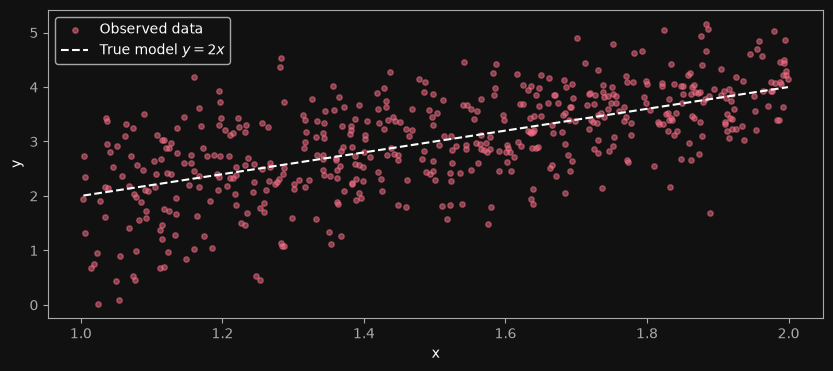

In [20]:
np.random.seed(500)
n = 500

x = np.random.uniform(1, 2, n)
sigma = 1 / x
epsilon = np.random.normal(0, sigma)
y = 2 * x + epsilon

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(x, y, alpha=0.5, s=15, label="Observed data")
ax.plot(np.sort(x), 2 * np.sort(x), color="white", ls="--", lw=1.5, label="True model $y = 2x$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
fig.savefig("./figures/problem4_scatter.png", dpi=300, bbox_inches="tight")

### 4.2

In [21]:
model_ols = sm.OLS(y, x).fit()
print(model_ols.summary().as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &        y         & \textbf{  R-squared (uncentered):}      &     0.949   \\
\textbf{Model:}            &       OLS        & \textbf{  Adj. R-squared (uncentered):} &     0.949   \\
\textbf{Method:}           &  Least Squares   & \textbf{  F-statistic:       }          &     9216.   \\
\textbf{Date:}             & Sat, 19 Sep 2026 & \textbf{  Prob (F-statistic):}          &     0.00    \\
\textbf{Time:}             &     08:46:57     & \textbf{  Log-Likelihood:    }          &   -540.20   \\
\textbf{No. Observations:} &         500      & \textbf{  AIC:               }          &     1082.   \\
\textbf{Df Residuals:}     &         499      & \textbf{  BIC:               }          &     1087.   \\
\textbf{Df Model:}         &           1      & \textbf{                     }          &             \\
\textbf{Covariance Type:}  &    nonrobust     & \textbf{                     }          &             \\
\bottomru

### 4.3

In [22]:
model_robust = sm.OLS(y, x).fit(cov_type="HC3")

comparison = pd.DataFrame(
    {
        "beta_hat": [model_ols.params[0], model_robust.params[0]],
        "std_err": [model_ols.bse[0], model_robust.bse[0]],
        "ci_lower": [model_ols.conf_int()[0][0], model_robust.conf_int()[0][0]],
        "ci_upper": [model_ols.conf_int()[0][1], model_robust.conf_int()[0][1]],
    },
    index=["OLS (conventional)", "OLS (HC3 robust)"],
)
print(comparison.to_latex(float_format="{:0.5f}".format))
print(f"ratio of standard errors: {model_ols.bse[0] / model_robust.bse[0]:.4f}")
print(f"theory, sqrt(E[1/x^2] E[x^2]) = sqrt(7/6) = {np.sqrt(7 / 6):.4f}")

\begin{tabular}{lrrrr}
\toprule
 & beta_hat & std_err & ci_lower & ci_upper \\
\midrule
OLS (conventional) & 1.99752 & 0.02081 & 1.95664 & 2.03840 \\
OLS (HC3 robust) & 1.99752 & 0.01962 & 1.95907 & 2.03596 \\
\bottomrule
\end{tabular}

ratio of standard errors: 1.0608
theory, sqrt(E[1/x^2] E[x^2]) = sqrt(7/6) = 1.0801


### 4.4

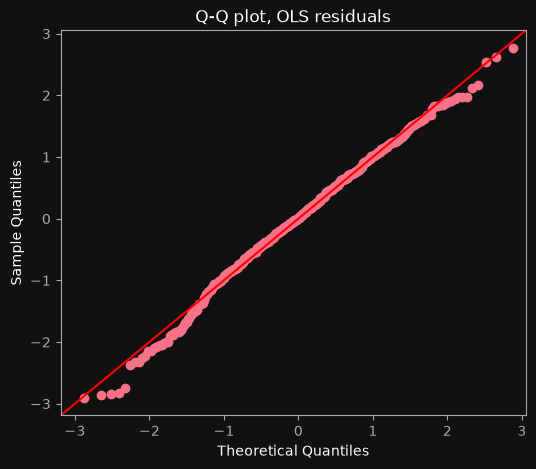

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
sm.qqplot(model_ols.resid, line="45", fit=True, ax=ax)
ax.set_title("Q-Q plot, OLS residuals")
fig.savefig("./figures/problem4_qq_ols.png", dpi=300, bbox_inches="tight")

### 4.5

In [24]:
model_wls = sm.WLS(y, x, weights=x**2).fit()
print(model_wls.summary().as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &        y         & \textbf{  R-squared (uncentered):}      &     0.960   \\
\textbf{Model:}            &       WLS        & \textbf{  Adj. R-squared (uncentered):} &     0.959   \\
\textbf{Method:}           &  Least Squares   & \textbf{  F-statistic:       }          & 1.183e+04   \\
\textbf{Date:}             & Sat, 19 Sep 2026 & \textbf{  Prob (F-statistic):}          &     0.00    \\
\textbf{Time:}             &     08:46:57     & \textbf{  Log-Likelihood:    }          &   -528.04   \\
\textbf{No. Observations:} &         500      & \textbf{  AIC:               }          &     1058.   \\
\textbf{Df Residuals:}     &         499      & \textbf{  BIC:               }          &     1062.   \\
\textbf{Df Model:}         &           1      & \textbf{                     }          &             \\
\textbf{Covariance Type:}  &    nonrobust     & \textbf{                     }          &             \\
\bottomru

### 4.6

\begin{tabular}{lrrr}
\toprule
 & std_dev & shapiro_p & corr_abs_resid_x \\
\midrule
OLS residuals & 0.7128 & 0.0482 & -0.2224 \\
Weighted (WLS) residuals & 1.0293 & 0.3125 & 0.0292 \\
\bottomrule
\end{tabular}



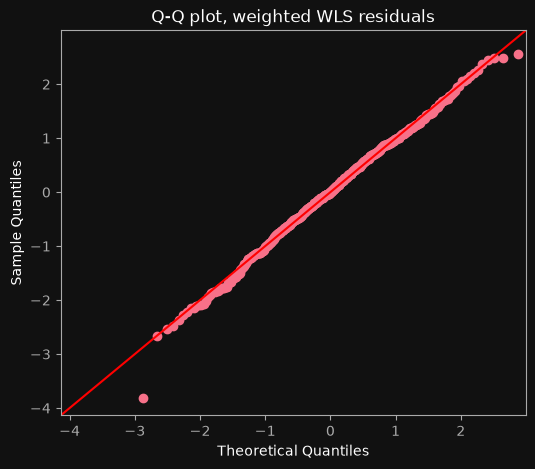

In [25]:
weighted_residuals = model_wls.wresid  # sqrt(w_i) * (y_i - x_i beta_hat)

fig, ax = plt.subplots(figsize=(6, 5))
sm.qqplot(weighted_residuals, line="45", fit=True, ax=ax)
ax.set_title("Q-Q plot, weighted WLS residuals")
fig.savefig("./figures/problem4_qq_wls.png", dpi=300, bbox_inches="tight")

diagnostics = pd.DataFrame(
    {
        "std_dev": [model_ols.resid.std(), weighted_residuals.std()],
        "shapiro_p": [
            stats.shapiro(model_ols.resid).pvalue,
            stats.shapiro(weighted_residuals).pvalue,
        ],
        "corr_abs_resid_x": [
            np.corrcoef(np.abs(model_ols.resid), x)[0, 1],
            np.corrcoef(np.abs(weighted_residuals), x)[0, 1],
        ],
    },
    index=["OLS residuals", "Weighted (WLS) residuals"],
)
print(diagnostics.to_latex(float_format="{:0.4f}".format))